In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

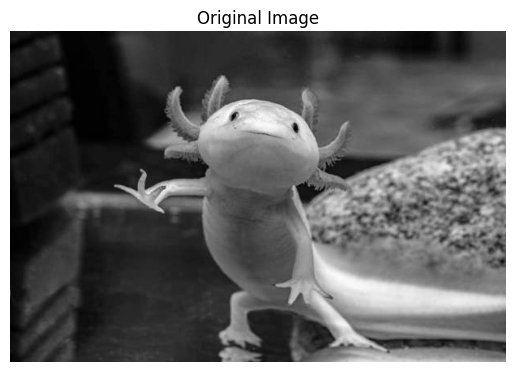

In [2]:
image_path = '../../input.jpg'
image_color = cv2.imread(image_path)
image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

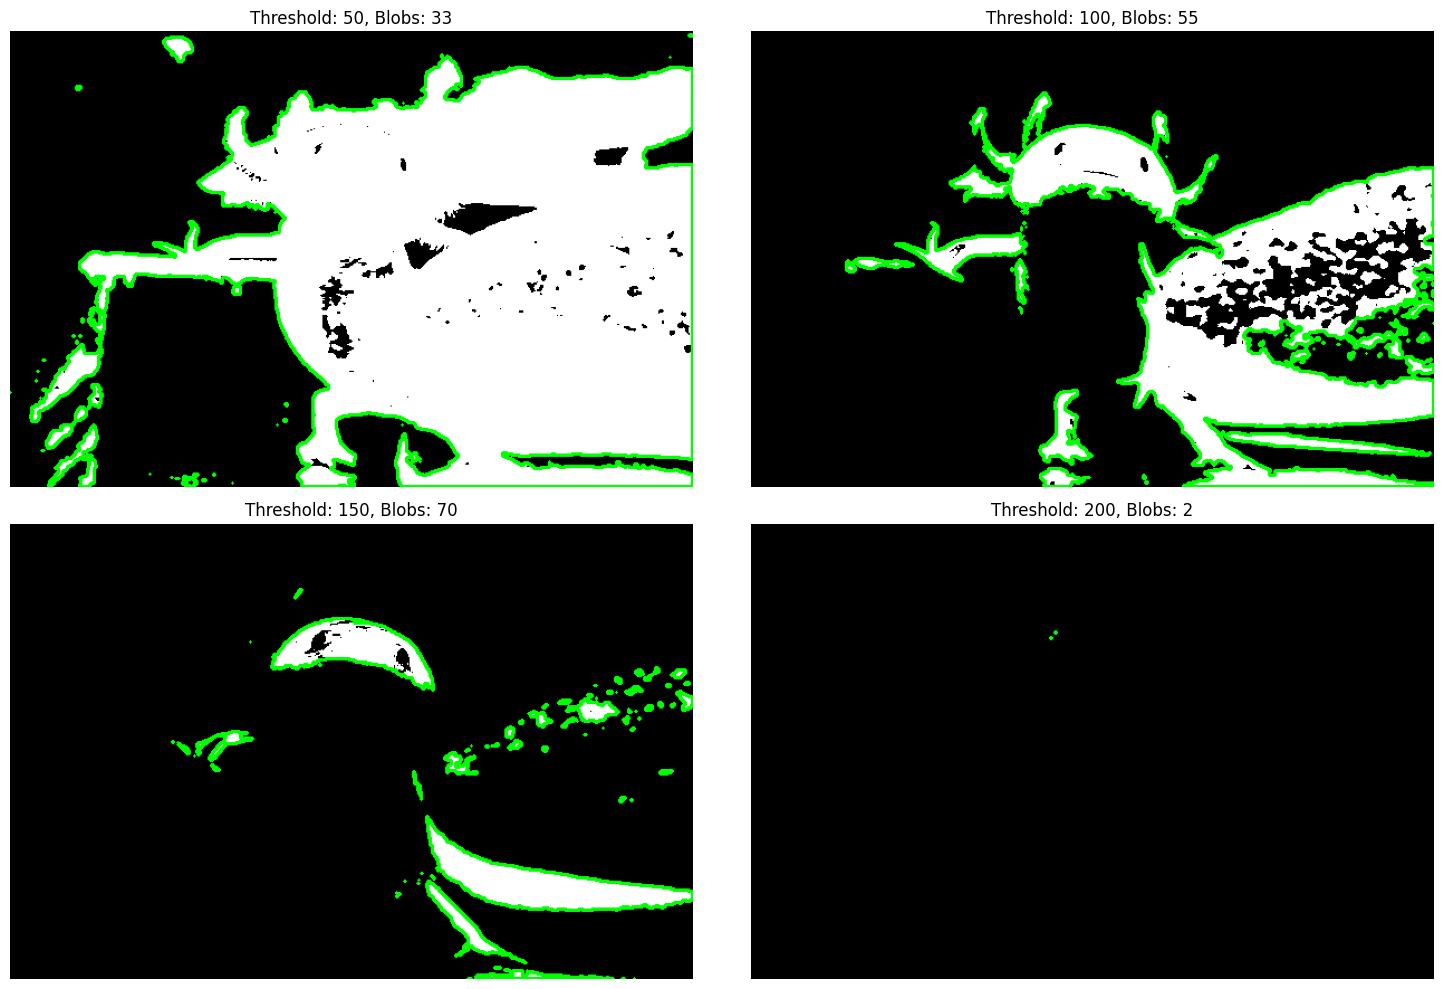

In [3]:
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

threshold_values = [50, 100, 150, 200]
plt.figure(figsize=(15, 10))

for idx, thresh_val in enumerate(threshold_values):
    _, binary = cv2.threshold(image, thresh_val, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    segmented = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(segmented, contours, -1, (0, 255, 0), 2)

    plt.subplot(2, 2, idx + 1)
    plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
    plt.title(f'Threshold: {thresh_val}, Blobs: {len(contours)}')
    plt.axis('off')

plt.tight_layout()
plt.show()

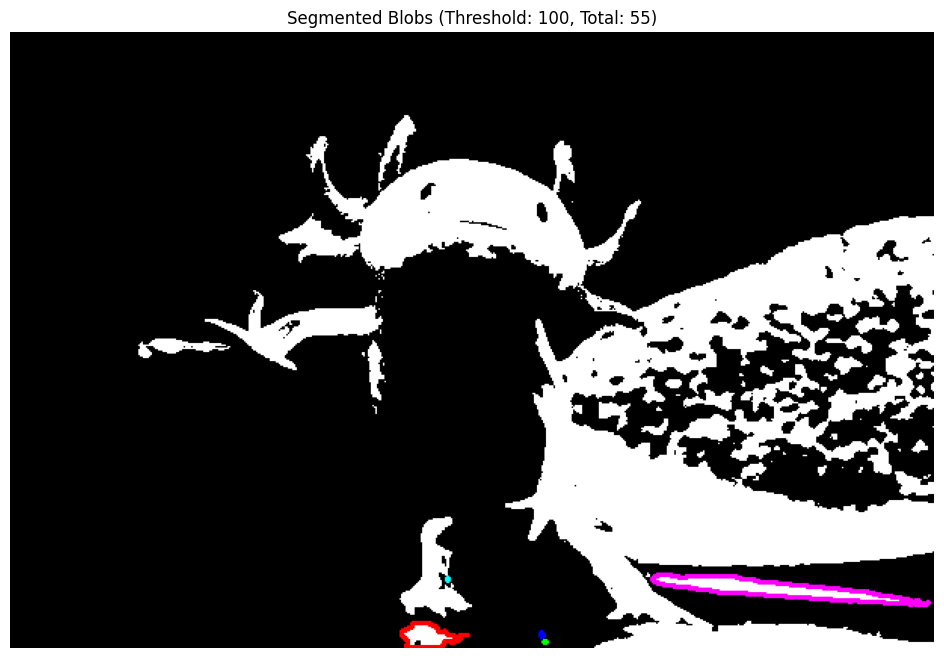

In [4]:
optimal_thresh = 100
_, binary = cv2.threshold(image, optimal_thresh, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

for i, contour in enumerate(contours[:5]):
    color = colors[i % len(colors)]
    cv2.drawContours(result, [contour], 0, color, 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'Segmented Blobs (Threshold: {optimal_thresh}, Total: {len(contours)})')
plt.axis('off')
plt.show()